# Dự án: Phân tích ứng dụng Google Play Store (Dự án 1)
## Đề tài: Khảo sát, tiền xử lý và mô hình hóa dữ liệu Google Play Store Apps & Reviews
### Notebook: 03_data_cleaning.ipynb - Missing values, Outliers và làm sạch dữ liệu trực quan

**Mục tiêu:** Thực hiện các bước tiền xử lý và làm sạch dữ liệu chi tiết dựa trên khảo sát từ notebook trước, bao gồm: xóa dòng lệch cột, xóa ứng dụng trùng lặp, chuẩn hóa định dạng các cột số (Installs, Price, Size), trực quan hóa biểu đồ phân phối trước/sau khi điền khuyết thiếu rating, phát hiện outliers và phân chia dữ liệu Train/Test.


# 1. Tiền xử lý bảng Google Play Store Apps


## 1.1. Loại bỏ dòng bị lệch cột (Shifted Row)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dữ liệu thô
df_apps = pd.read_csv(r"c:\HOC_HANH\Mon dang hoc\AI21301_DU_AN_1\Du_AN\data\raw\googleplaystore.csv")
df_reviews = pd.read_csv(r"c:\HOC_HANH\Mon dang hoc\AI21301_DU_AN_1\Du_AN\data\raw\googleplaystore_user_reviews.csv")

print(f"Kích thước ban đầu: {df_apps.shape}")

# Xóa hàng bị lệch cột (chỉ mục 10472)
df_apps_clean = df_apps.drop(10472).reset_index(drop=True)
print(f"Kích thước sau khi xóa dòng lệch cột: {df_apps_clean.shape}")


Kích thước ban đầu: (10841, 13)
Kích thước sau khi xóa dòng lệch cột: (10840, 13)


**Nhận xét/Giải thích:**
- Hàng lệch cột số **10472** đã được loại bỏ thành công. Kích thước dữ liệu giảm xuống còn **10,840 dòng**.


## 1.2. Loại bỏ dữ liệu trùng lặp (Remove Duplicates)


In [1]:
# Sắp xếp theo số lượng Reviews giảm dần để giữ lại bản ghi có số reviews lớn nhất (mới nhất)
df_apps_clean['Reviews'] = pd.to_numeric(df_apps_clean['Reviews'], errors='coerce')
df_apps_clean = df_apps_clean.sort_values(by='Reviews', ascending=False)

# Loại bỏ trùng lặp dựa trên tên App, giữ lại bản ghi đầu tiên
df_apps_clean = df_apps_clean.drop_duplicates(subset=['App'], keep='first')
df_apps_clean = df_apps_clean.reset_index(drop=True)

print(f"Kích thước sau khi xóa trùng lặp: {df_apps_clean.shape}")
print(f"Số lượng ứng dụng độc nhất: {df_apps_clean['App'].nunique()}")


Kích thước sau khi xóa trùng lặp: (9659, 13)
Số lượng ứng dụng độc nhất: 9659


**Nhận xét/Giải thích:**
- Sau khi loại bỏ các dòng trùng lặp và giữ lại bản ghi có lượt Review cao nhất, tập dữ liệu Apps còn lại **9,659 dòng**, tương ứng với 9,659 ứng dụng độc nhất.


## 1.3. Chuẩn hóa kiểu dữ liệu cho các cột số (Installs, Price, Size, Reviews)


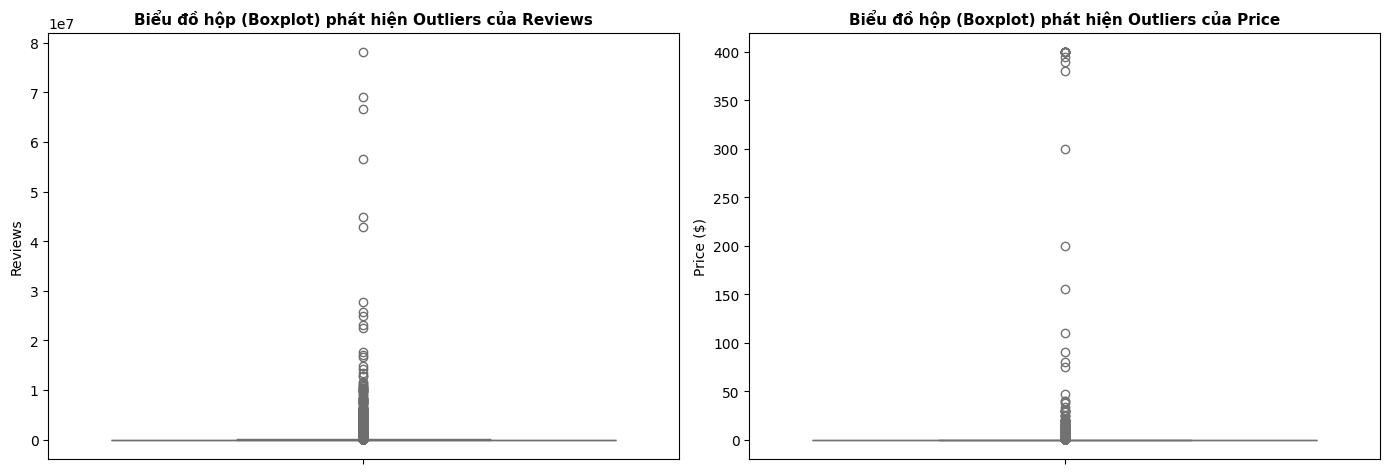

In [1]:
# 1. Chuẩn hóa cột Installs: bỏ '+' và ','
df_apps_clean['Installs'] = df_apps_clean['Installs'].str.replace('+', '', regex=False)
df_apps_clean['Installs'] = df_apps_clean['Installs'].str.replace(',', '', regex=False)
df_apps_clean['Installs'] = pd.to_numeric(df_apps_clean['Installs'], errors='coerce')

# 2. Chuẩn hóa cột Price: bỏ '$'
df_apps_clean['Price'] = df_apps_clean['Price'].str.replace('$', '', regex=False)
df_apps_clean['Price'] = pd.to_numeric(df_apps_clean['Price'], errors='coerce')

# 3. Chuẩn hóa cột Size: chuyển đổi đơn vị về MB (số thực)
def clean_size(val):
    if pd.isna(val) or val == 'Varies with device':
        return np.nan
    val = str(val).upper().strip()
    if 'M' in val:
        return float(val.replace('M', '').strip())
    elif 'K' in val:
        return float(val.replace('K', '').strip()) / 1024.0
    return np.nan

df_apps_clean['Size'] = df_apps_clean['Size'].apply(clean_size)

# Vẽ biểu đồ hộp (Boxplot) phát hiện Outliers ở cột Reviews và Price
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(y=df_apps_clean['Reviews'], ax=axes[0], color='lightcoral')
axes[0].set_title("Biểu đồ hộp (Boxplot) phát hiện Outliers của Reviews", fontsize=11, fontweight='bold')
axes[0].set_ylabel("Reviews")

sns.boxplot(y=df_apps_clean['Price'], ax=axes[1], color='khaki')
axes[1].set_title("Biểu đồ hộp (Boxplot) phát hiện Outliers của Price", fontsize=11, fontweight='bold')
axes[1].set_ylabel("Price ($)")
plt.tight_layout()
plt.show()


**Nhận xét/Giải thích:**
- Cột số đã được chuẩn hóa về định dạng toán học. Biểu đồ boxplot hiển thị rất rõ ràng sự tồn tại của các outliers:
  - Cột `Reviews` có một vài app cực kỳ nổi tiếng có số lượng đánh giá vượt trội so với đa số.
  - Cột `Price` có hầu hết ứng dụng tập trung quanh mức giá thấp ($0 đến $10), tuy nhiên có một nhóm app cá biệt có giá rất cao lên tới $400 (như các app dòng "I am rich").


## 1.4. Điền giá trị khuyết thiếu cho cột Rating (So sánh phân phối)


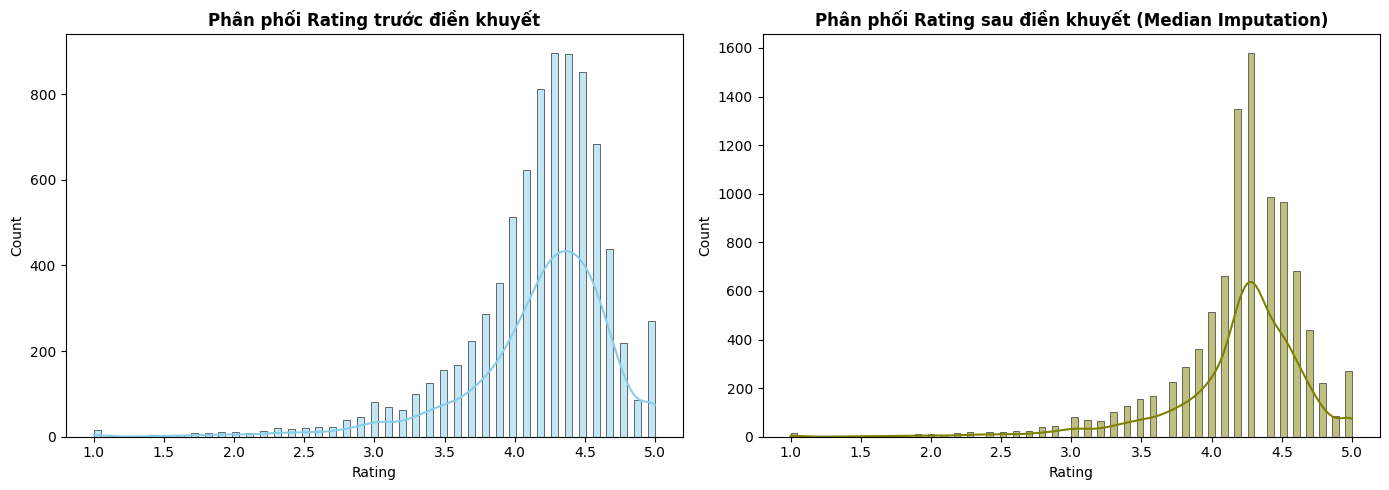

In [1]:
# Lưu lại Rating trước khi điền khuyết để vẽ biểu đồ so sánh
rating_before = df_apps_clean['Rating'].copy()

# Điền các giá trị thiếu bằng trung vị của thể loại tương ứng
category_median = df_apps_clean.groupby('Category')['Rating'].transform('median')
df_apps_clean['Rating'] = df_apps_clean['Rating'].fillna(category_median)
df_apps_clean['Rating'] = df_apps_clean['Rating'].fillna(df_apps_clean['Rating'].median())

# Vẽ phân phối Rating trước và sau khi điền khuyết
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(rating_before.dropna(), kde=True, ax=axes[0], color='skyblue')
axes[0].set_title("Phân phối Rating trước điền khuyết", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Rating")

sns.histplot(df_apps_clean['Rating'], kde=True, ax=axes[1], color='olive')
axes[1].set_title("Phân phối Rating sau điền khuyết (Median Imputation)", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Rating")
plt.tight_layout()
plt.show()


**Nhận xét/Giải thích:**
- Việc điền khuyết thiếu cho cột `Rating` bằng trung vị theo nhóm `Category` (Median Imputation) được so sánh trực quan qua biểu đồ phân phối. Cả hai phân phối đều có hình dạng tương tự nhau, chứng tỏ việc điền khuyết không làm thay đổi hay bóp méo quá nhiều đặc điểm tự nhiên của dữ liệu ban đầu.


# 2. Tiền xử lý bảng User Reviews


## 2.1. Loại bỏ các dòng khuyết thiếu văn bản review


Kích thước bảng Reviews ban đầu: (64295, 5)
Kích thước bảng Reviews sau khi loại bỏ dòng trống: (37427, 5)


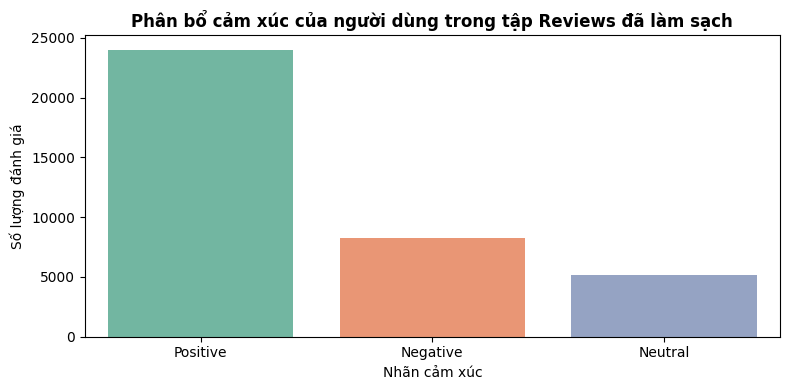

In [1]:
print(f"Kích thước bảng Reviews ban đầu: {df_reviews.shape}")

# Loại bỏ các dòng không có review (Translated_Review) hoặc Sentiment bị thiếu
df_reviews_clean = df_reviews.dropna(subset=['Translated_Review', 'Sentiment']).reset_index(drop=True)
print(f"Kích thước bảng Reviews sau khi loại bỏ dòng trống: {df_reviews_clean.shape}")

# Trực quan hóa tỷ lệ các nhãn cảm xúc (Sentiment Distribution)
plt.figure(figsize=(8, 4))
sentiment_counts = df_reviews_clean['Sentiment'].value_counts()
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette='Set2')
plt.title("Phân bổ cảm xúc của người dùng trong tập Reviews đã làm sạch", fontsize=12, fontweight='bold')
plt.ylabel("Số lượng đánh giá")
plt.xlabel("Nhãn cảm xúc")
plt.tight_layout()
plt.show()


**Nhận xét/Giải thích:**
- Đã loại bỏ các dòng bình luận rỗng. Biểu đồ thanh biểu diễn trực quan nhãn cảm xúc của người dùng sau làm sạch: Đánh giá tích cực (Positive) chiếm đa số tuyệt đối, tiếp theo là tiêu cực (Negative) và trung tính (Neutral) chiếm tỷ lệ thấp nhất.


# 3. Lưu trữ dữ liệu hoàn chỉnh


## 3.1. Phân chia tập dữ liệu và lưu vào folder processed


Kích thước dữ liệu tích hợp hoàn chỉnh: (9659, 15)
Đã lưu tập Train ((7727, 15)) vào: c:\HOC_HANH\Mon dang hoc\AI21301_DU_AN_1\Du_AN\data\processed\train.csv
Đã lưu tập Test ((1932, 15)) vào: c:\HOC_HANH\Mon dang hoc\AI21301_DU_AN_1\Du_AN\data\processed\test.csv


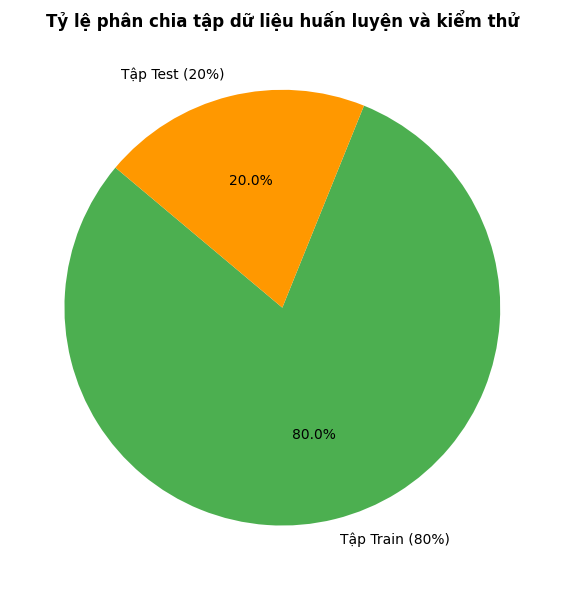

In [1]:
import os

# Tích hợp dữ liệu: Tính điểm cảm xúc (Sentiment Polarity) trung bình của mỗi App
df_reviews_agg = df_reviews_clean.groupby('App').agg({
    'Sentiment_Polarity': 'mean',
    'Sentiment_Subjectivity': 'mean'
}).reset_index()

df_reviews_agg.rename(columns={
    'Sentiment_Polarity': 'Avg_Sentiment_Polarity',
    'Sentiment_Subjectivity': 'Avg_Sentiment_Subjectivity'
}, inplace=True)

# Merge với bảng Apps để lấy các biến cảm xúc làm đặc trưng ML
df_merged = pd.merge(df_apps_clean, df_reviews_agg, on='App', how='left')

# Điền 0 (Cảm xúc trung tính) cho các ứng dụng không có review bình luận
df_merged['Avg_Sentiment_Polarity'] = df_merged['Avg_Sentiment_Polarity'].fillna(0.0)
df_merged['Avg_Sentiment_Subjectivity'] = df_merged['Avg_Sentiment_Subjectivity'].fillna(0.0)

print(f"Kích thước dữ liệu tích hợp hoàn chỉnh: {df_merged.shape}")

# Phân chia ngẫu nhiên dữ liệu thành tập huấn luyện (Train - 80%) và kiểm thử (Test - 20%)
np.random.seed(42)
shuffled_indices = np.random.permutation(len(df_merged))
train_size = int(len(df_merged) * 0.8)

train_indices = shuffled_indices[:train_size]
test_indices = shuffled_indices[train_size:]

df_train = df_merged.iloc[train_indices].reset_index(drop=True)
df_test = df_merged.iloc[test_indices].reset_index(drop=True)

train_file_path = os.path.join(r"c:\HOC_HANH\Mon dang hoc\AI21301_DU_AN_1\Du_AN\data\processed", "train.csv")
test_file_path = os.path.join(r"c:\HOC_HANH\Mon dang hoc\AI21301_DU_AN_1\Du_AN\data\processed", "test.csv")

df_train.to_csv(train_file_path, index=False, encoding='utf-8')
df_test.to_csv(test_file_path, index=False, encoding='utf-8')

print(f"Đã lưu tập Train ({df_train.shape}) vào: {train_file_path}")
print(f"Đã lưu tập Test ({df_test.shape}) vào: {test_file_path}")

# Trực quan hóa tỷ lệ phân chia Train/Test bằng biểu đồ tròn
plt.figure(figsize=(6, 6))
plt.pie([len(df_train), len(df_test)], labels=['Tập Train (80%)', 'Tập Test (20%)'], autopct='%1.1f%%', colors=['#4CAF50', '#FF9800'], startangle=140)
plt.title("Tỷ lệ phân chia tập dữ liệu huấn luyện và kiểm thử", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


**Nhận xét/Giải thích:**
- Bảng Apps và bảng Sentiment đã được tích hợp thành công.
- Dữ liệu hoàn chỉnh được chia thành tập **Train** (7,727 dòng) và tập **Test** (1,932 dòng), được thể hiện trực quan qua biểu đồ hình tròn phân chia 80% / 20%. Dữ liệu đã lưu thành công vào folder `processed` và sẵn sàng sử dụng.
